## Machine Learning Workshop : Wine
### Regression Task:

#### Task:
On column 'alcohol' with hyper parameter tunning achive better performance (R2 Score over 0.7) model and prevent overfitting.

#### 1. Imports:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from scipy.stats import randint
from random import randint
from sklearn.datasets import load_wine
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor, LocalOutlierFactor
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')


#### 2. Data:

In [2]:
data = load_wine().data
df = pd.DataFrame(data, columns=load_wine().feature_names)


In [3]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [ ]:
df.shape 

(178, 13)

In [5]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
df.info

<bound method DataFrame.info of      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  no

In [7]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


##### Data Split -> (X, y)

In [8]:
X = df.drop('alcohol', axis=1)
y = df['alcohol']

In [ ]:
X.shape  
#y.shape 

(178, 12)

#### 3. EDA:

In [10]:
# Check duplicates
X.duplicated().sum()  # -> 0


np.int64(0)

In [11]:
# Check Null
X.isna().sum()     # -> 0


malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

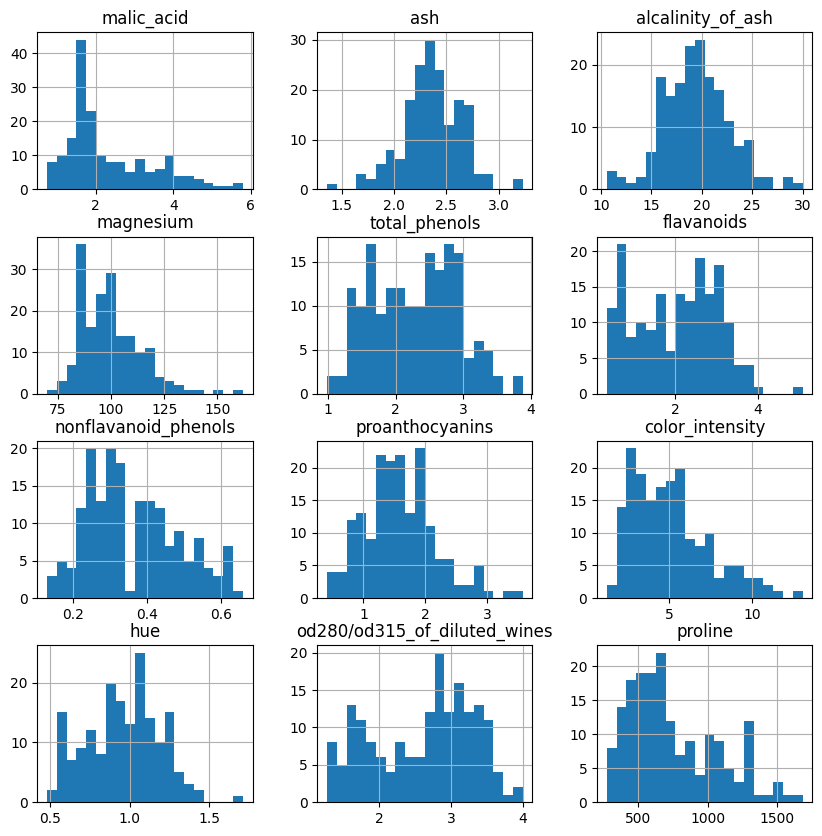

In [12]:
# Column Data Shape
X.hist(bins=20, figsize=(10, 10));

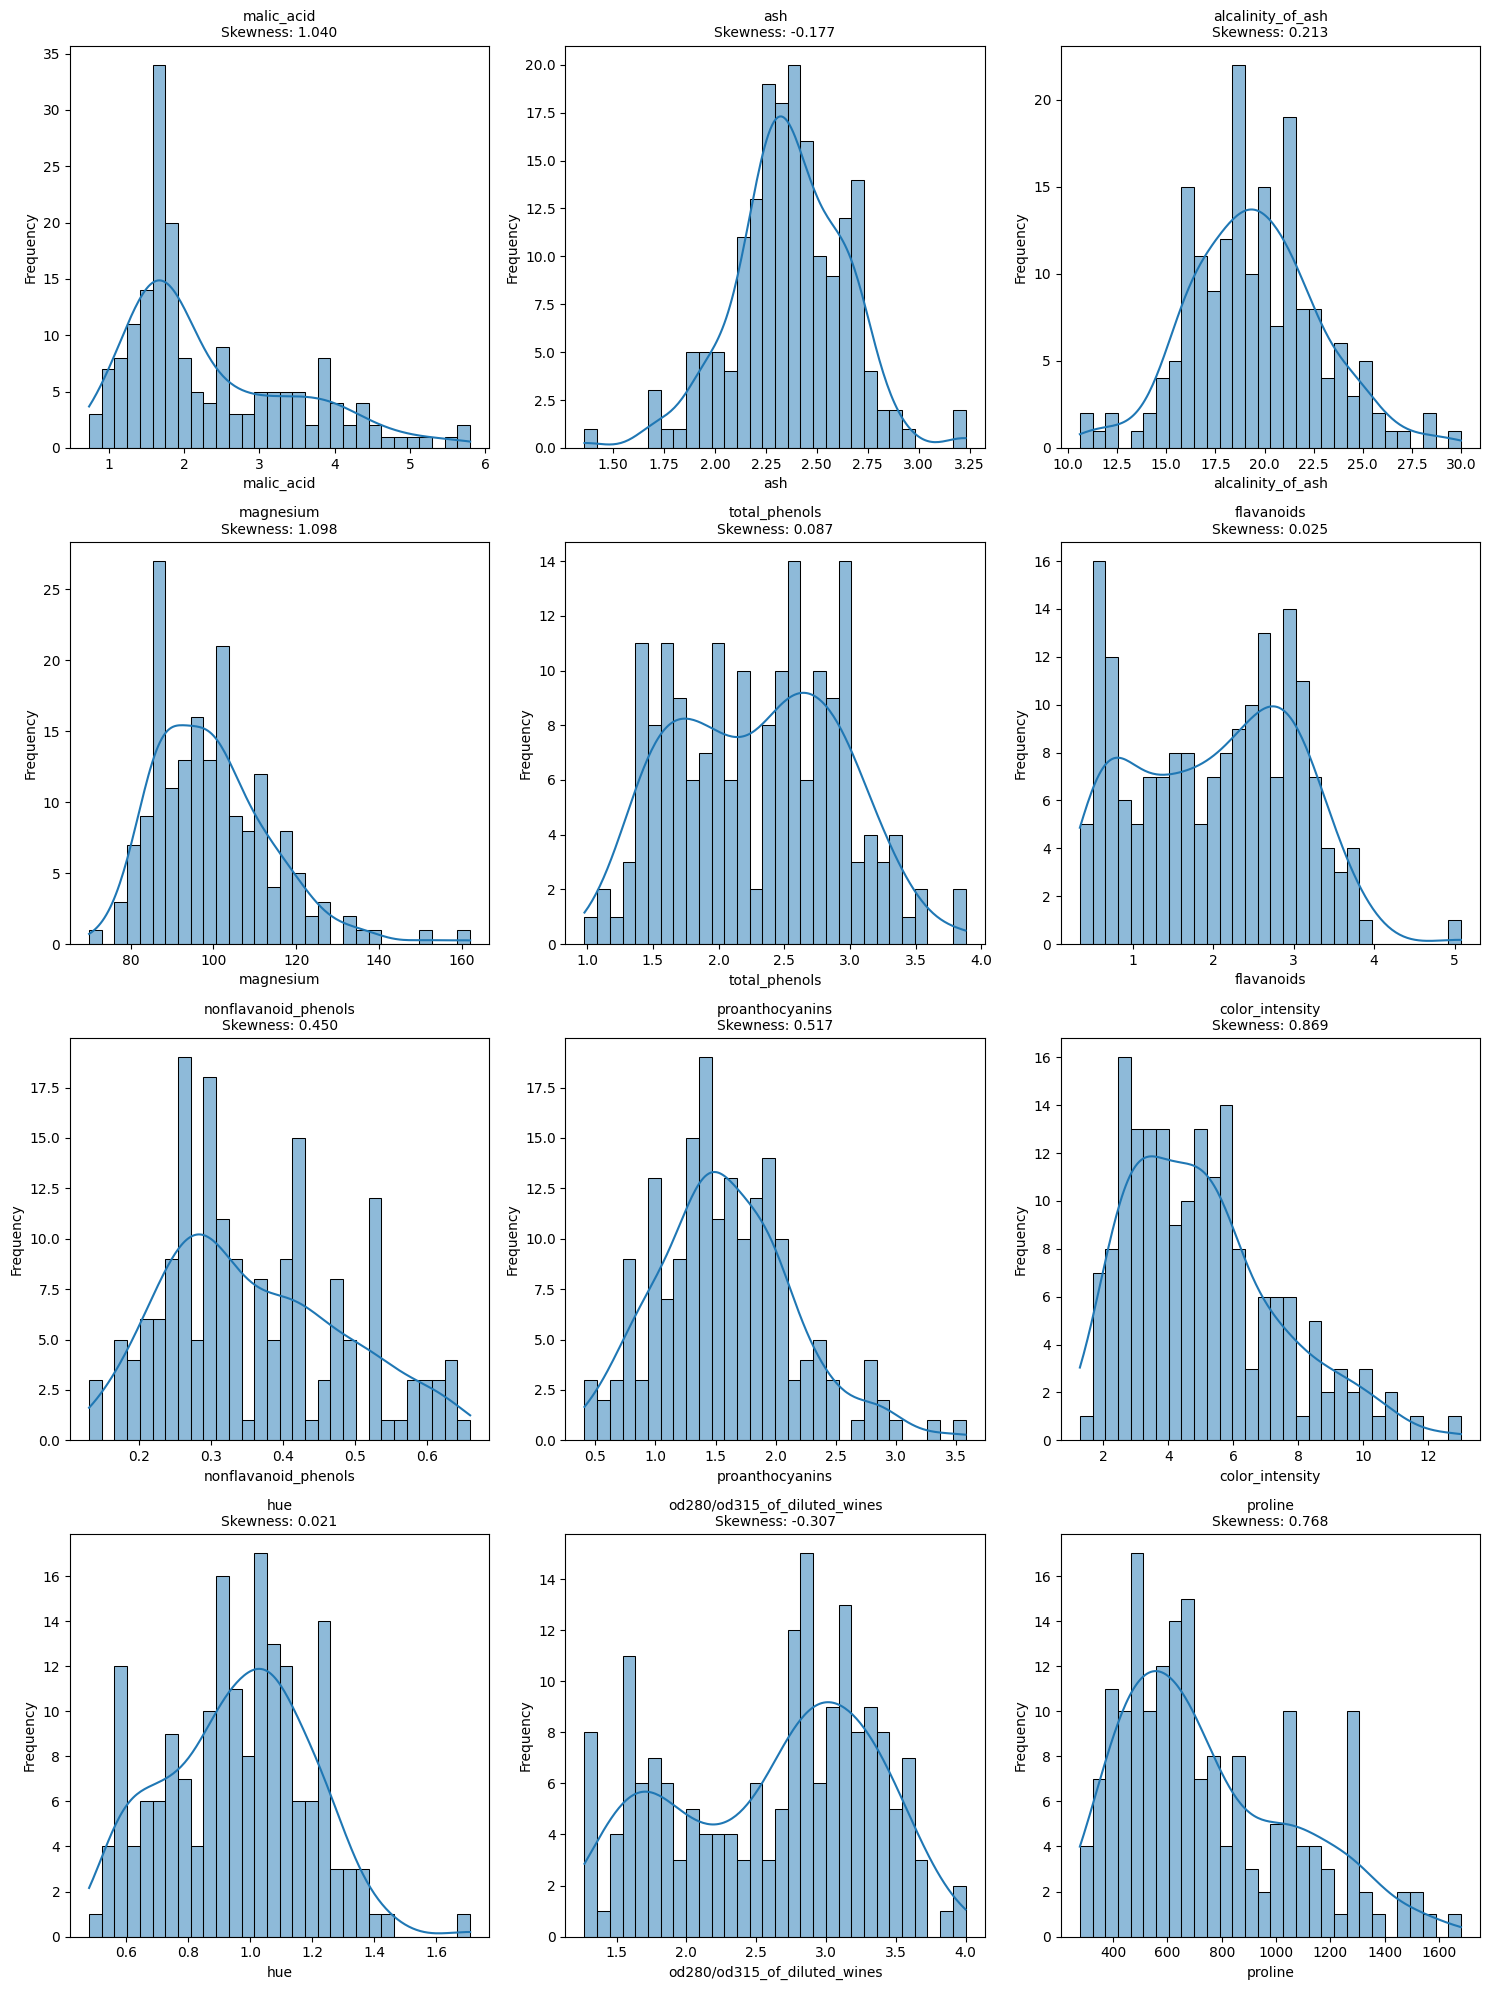

In [13]:
# Skewness in Chart
# Calculate number of rows and columns needed
new_df = df.drop('alcohol', axis=1)
n_cols = len(new_df.columns)
n_rows = (n_cols + 2) // 3  # 3 plots per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten for easy iteration

for i, col in enumerate(new_df.columns):
    # Plot histogram with KDE
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=30)
    
    # Add skewness text
    skewness = new_df[col].skew()
    axes[i].set_title(f'{col}\nSkewness: {skewness:.3f}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Remove empty subplots
for i in range(len(new_df.columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

COLUMN STATISTICS
                      Column  Non_Zero_Count  Non_Zero_Percent     Variance  Unique_Values     Max
                  malic_acid             178             100.0     1.248015            133    5.80
                         ash             178             100.0     0.075265             79    3.23
           alcalinity_of_ash             178             100.0    11.152686             63   30.00
                   magnesium             178             100.0   203.989335             53  162.00
               total_phenols             178             100.0     0.391690             97    3.88
                  flavanoids             178             100.0     0.997719            132    5.08
        nonflavanoid_phenols             178             100.0     0.015489             39    0.66
             proanthocyanins             178             100.0     0.327595            101    3.58
             color_intensity             178             100.0     5.374449            132 

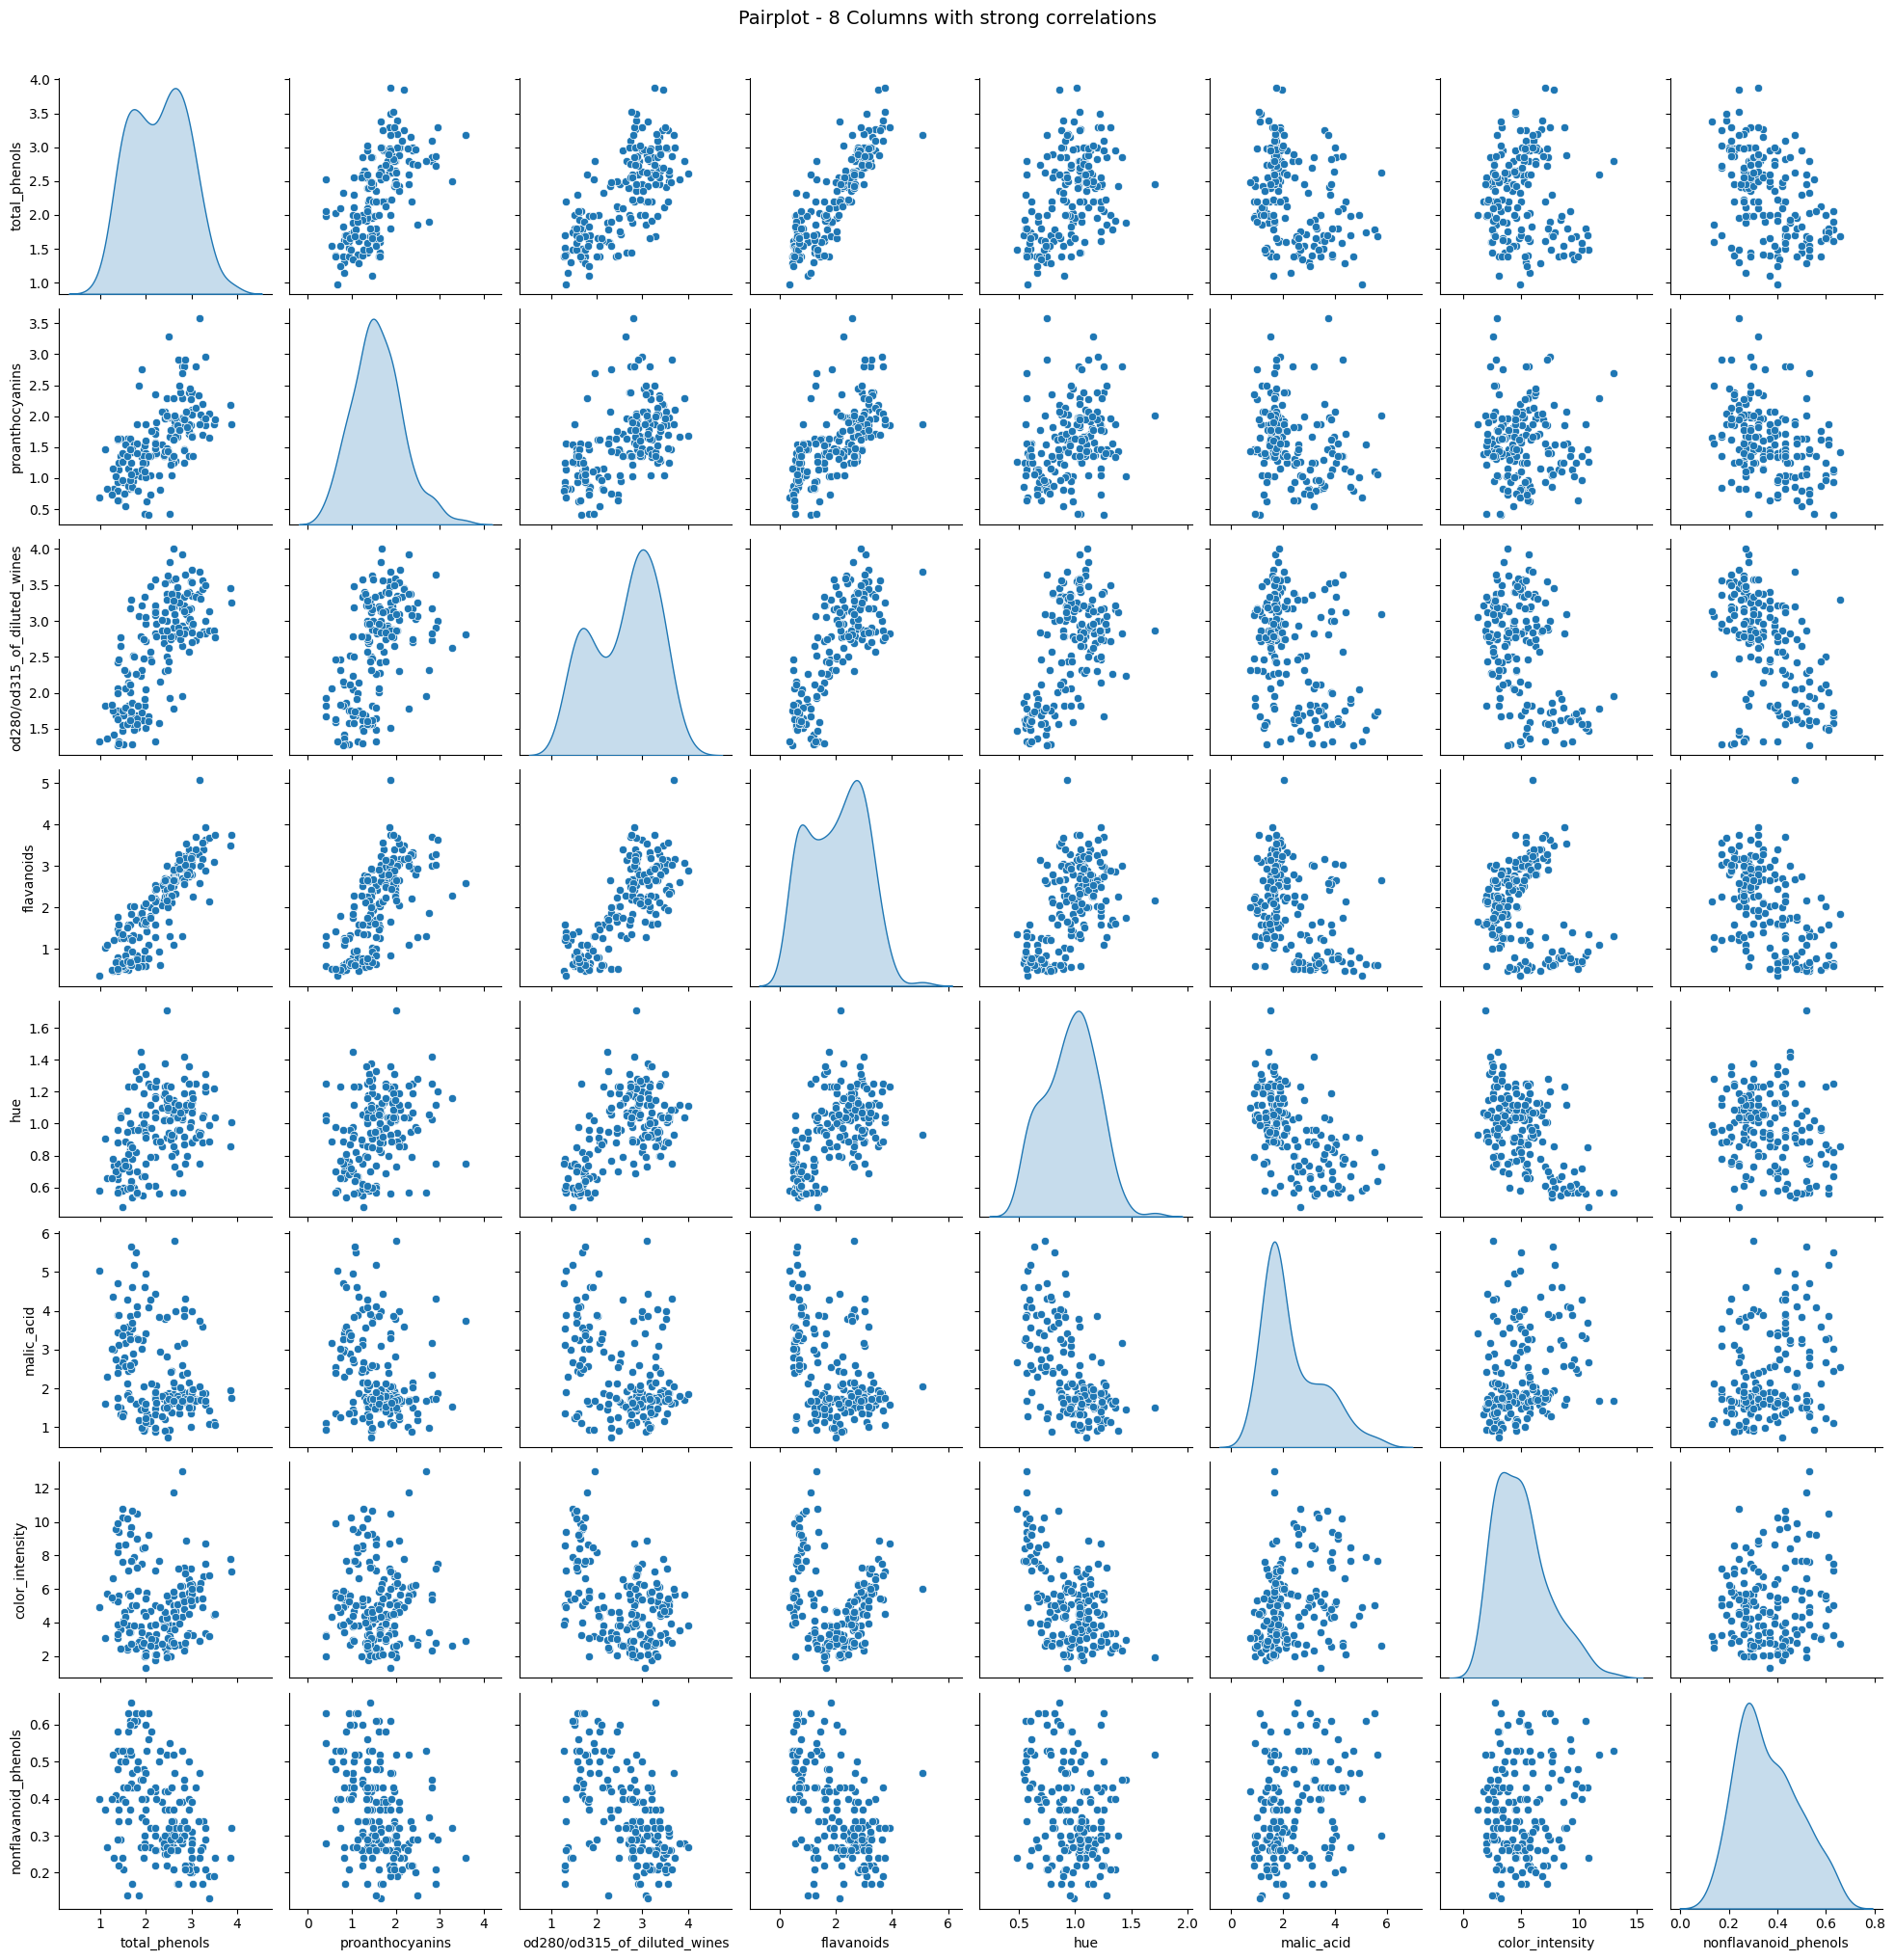

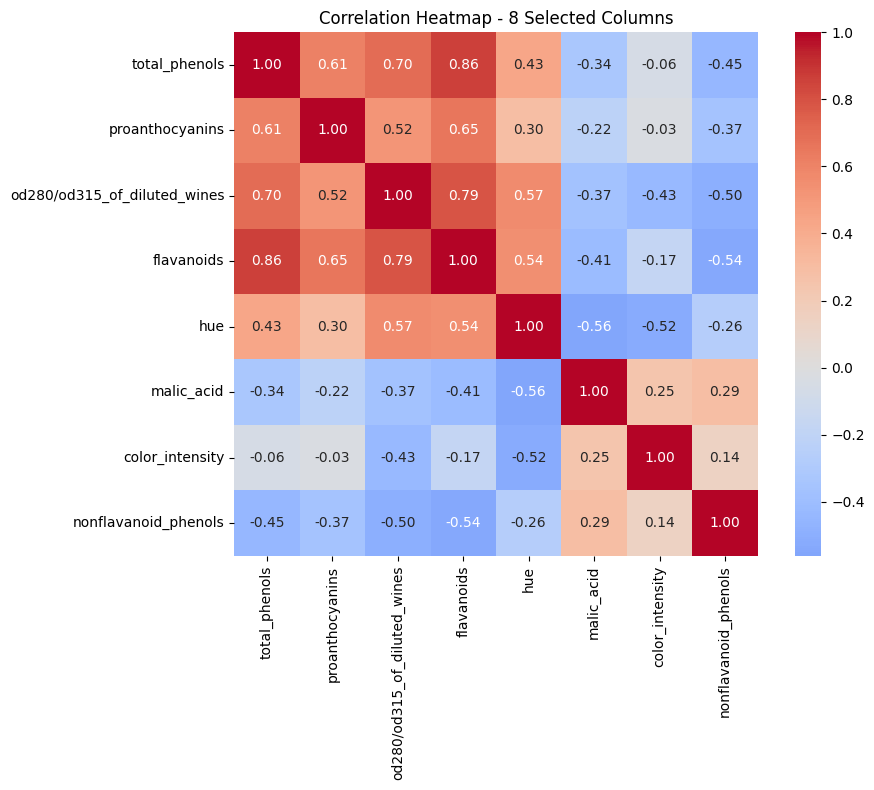

In [14]:
# Correlation 
def smart_correlation_analysis(new_df, corr_threshold=0.5, max_plot_cols=10):
    """
    Smart correlation analysis for sparse data like yours
    """
    # Step 1: Identify columns with variation
    col_stats = []
    for col in new_df.columns:
        non_zero = (new_df[col] != 0).sum()
        variance = new_df[col].var()
        unique_vals = new_df[col].nunique()
        
        col_stats.append({
            'Column': col,
            'Non_Zero_Count': non_zero,
            'Non_Zero_Percent': (non_zero / len(new_df)) * 100,
            'Variance': variance,
            'Unique_Values': unique_vals,
            'Max': df[col].max()
        })
    
    col_stats_df = pd.DataFrame(col_stats)
    
    # Step 2: Filter meaningful columns
    meaningful_cols = col_stats_df[
        (col_stats_df['Variance'] > 0) | 
        (col_stats_df['Non_Zero_Count'] > 1)
    ]
    
    print("="*60)
    print("COLUMN STATISTICS")
    print("="*60)
    print(meaningful_cols.to_string(index=False))
    
    if len(meaningful_cols) < 2:
        print("\n⚠️ Only 1 or fewer columns have variation. Cannot compute correlations.")
        return None
    
    # Step 3: Calculate correlations
    df_filtered = new_df[meaningful_cols['Column'].tolist()]
    corr_matrix = df_filtered.corr()
    
    # Step 4: Find strong correlations
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            corr_pairs.append({
                'Column 1': col1,
                'Column 2': col2,
                'Correlation': corr_val,
                'Abs_Correlation': abs(corr_val)
            })
    
    corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Abs_Correlation', ascending=False)
    
    print("\n" + "="*60)
    print("TOP CORRELATIONS")
    print("="*60)
    print(corr_pairs_df.head(10).to_string(index=False))
    
    # Step 5: Select columns for visualization
    strong_corrs = corr_pairs_df[corr_pairs_df['Abs_Correlation'] > corr_threshold]
    
    if len(strong_corrs) > 0:
        cols_to_plot = set()
        for _, row in strong_corrs.iterrows():
            cols_to_plot.add(row['Column 1'])
            cols_to_plot.add(row['Column 2'])
        cols_to_plot = list(cols_to_plot)[:max_plot_cols]
        plot_type = "strong correlations"
    else:
        # Take top columns by variance
        cols_to_plot = meaningful_cols.nlargest(max_plot_cols, 'Variance')['Column'].tolist()
        plot_type = "highest variance"
    
    # Step 6: Create visualizations
    if len(cols_to_plot) >= 2:
        print(f"\n" + "="*60)
        print(f"PLOTTING {len(cols_to_plot)} COLUMNS WITH {plot_type.upper()}")
        print("="*60)
        print(f"Columns: {cols_to_plot}")
        
        # Pairplot
        fig = sns.pairplot(new_df[cols_to_plot], diag_kind='kde')
        fig.fig.suptitle(f'Pairplot - {len(cols_to_plot)} Columns with {plot_type}', 
                        y=1.02, fontsize=14)
        plt.show()
        
        # Heatmap for these columns
        plt.figure(figsize=(10, 8))
        sns.heatmap(new_df[cols_to_plot].corr(), 
                   annot=True, 
                   cmap='coolwarm', 
                   center=0,
                   fmt='.2f',
                   square=True)
        plt.title(f'Correlation Heatmap - {len(cols_to_plot)} Selected Columns')
        plt.tight_layout()
        plt.show()
        
        return cols_to_plot
    else:
        print("\n⚠️ Not enough columns to create pairplot (need at least 2)")
        return None

# Usage for your data
selected_cols = smart_correlation_analysis(new_df, corr_threshold=0.5, max_plot_cols=8)

In [15]:
# Outliers
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_outliers = clf.fit_predict(X)

# Create outlier column (-1 = outlier, 1 = inlier)
X['outlier'] = y_pred_outliers

# Separate dataframes
outliers_df = X[X['outlier'] == -1]  # Outliers only
inliers_df = X[X['outlier'] == 1]    # Inliers only

print(f"Total samples: {len(X)}")
print(f"Outliers found: {len(outliers_df)}")
print(f"Inliers: {len(inliers_df)}")
print(f"\nOutlier indices: {outliers_df.index.tolist()}")

Total samples: 178
Outliers found: 18
Inliers: 160

Outlier indices: [3, 5, 10, 14, 18, 31, 53, 68, 69, 78, 80, 93, 94, 105, 108, 111, 117, 128]


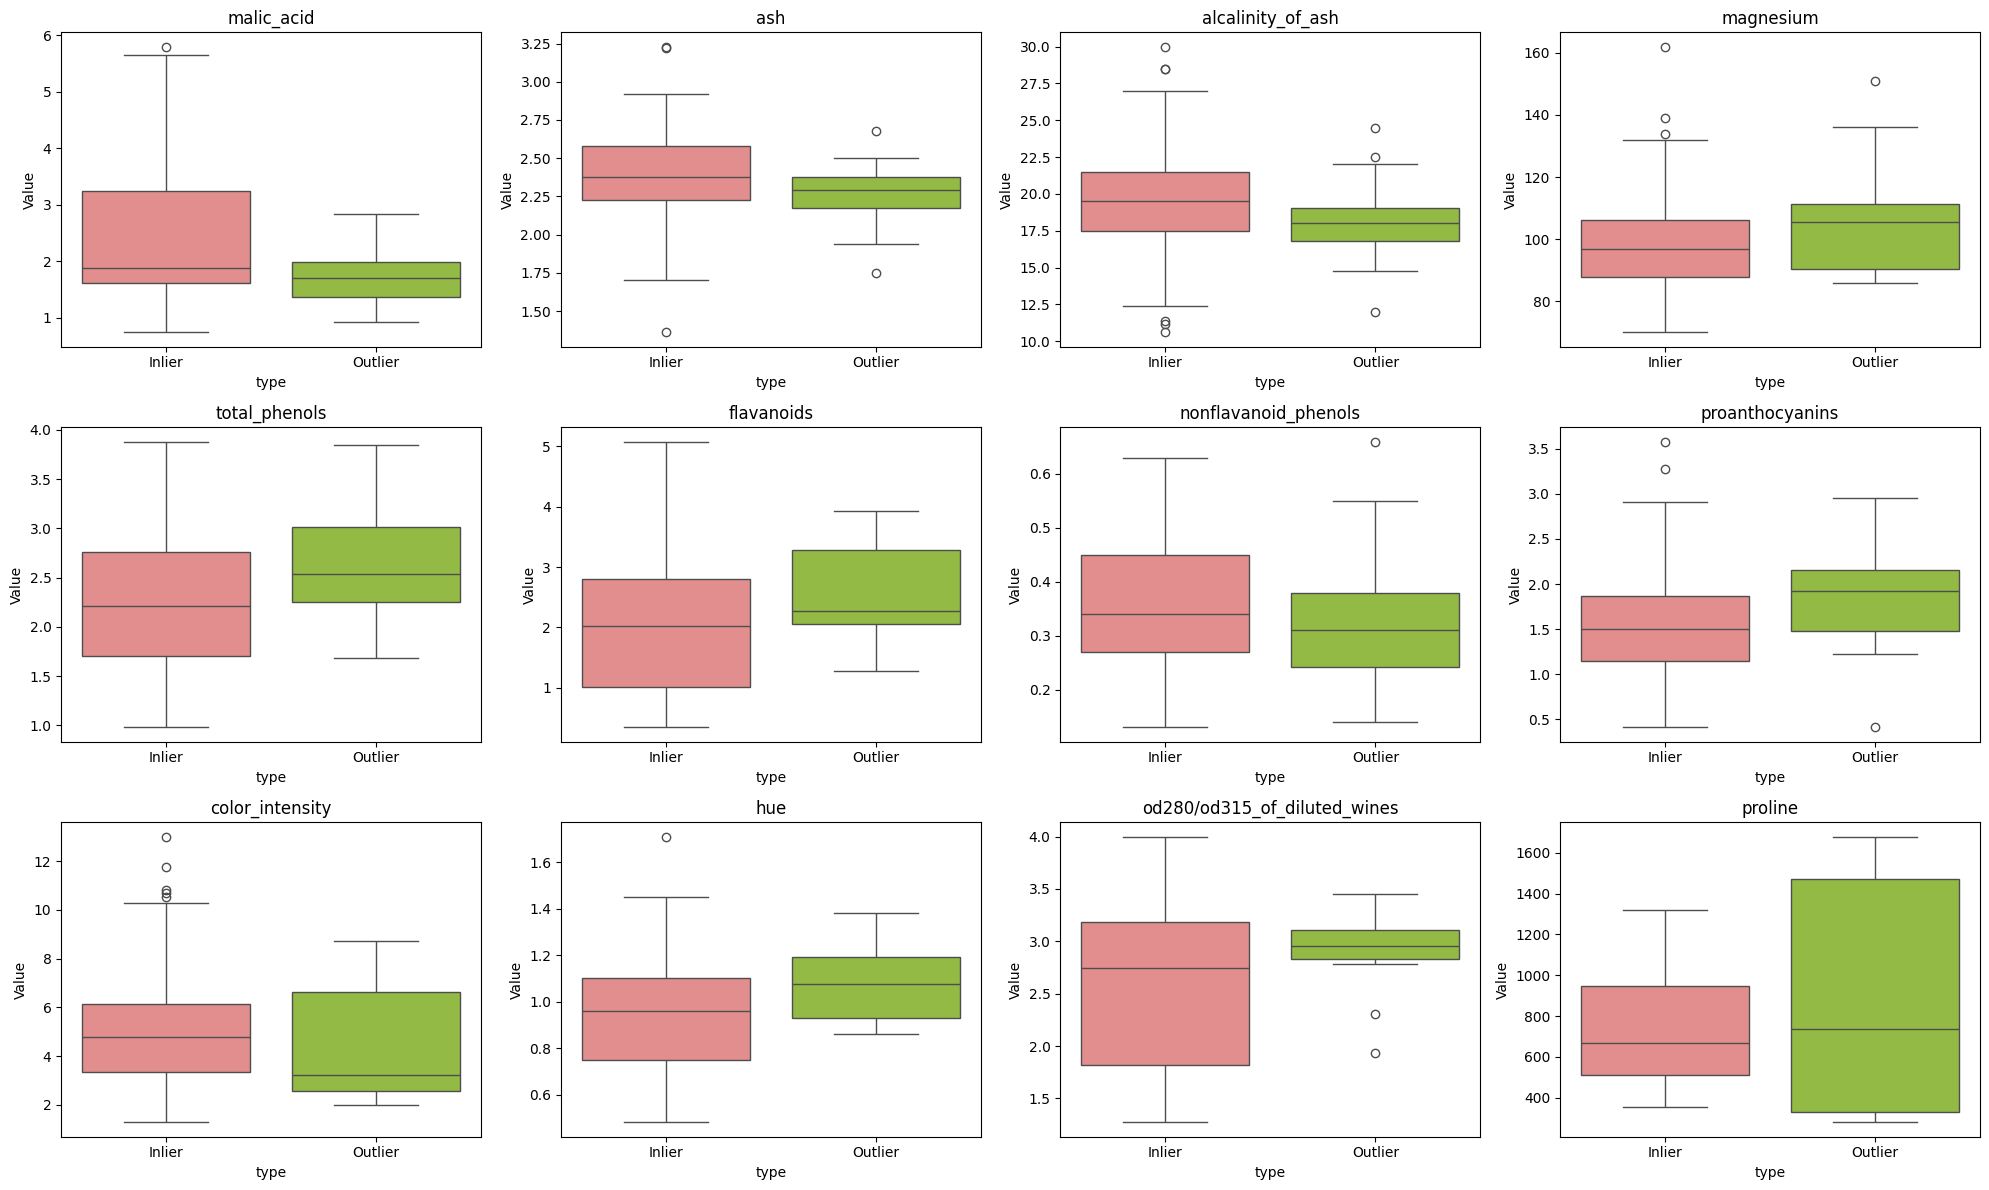

In [16]:
# Outliers in Chart
# Create a figure with multiple subplots
feature_names = X.columns
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for idx, feature in enumerate(feature_names[:12]):  # All 12 features
    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'value': X[feature],
        'type': X['outlier'].map({1: 'Inlier', -1: 'Outlier'})
    })
    
    # Boxplot
    sns.boxplot(x='type', y='value', data=plot_df, ax=axes[idx], palette=['lightcoral', 'yellowgreen'])
    axes[idx].set_title(f'{feature}')
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

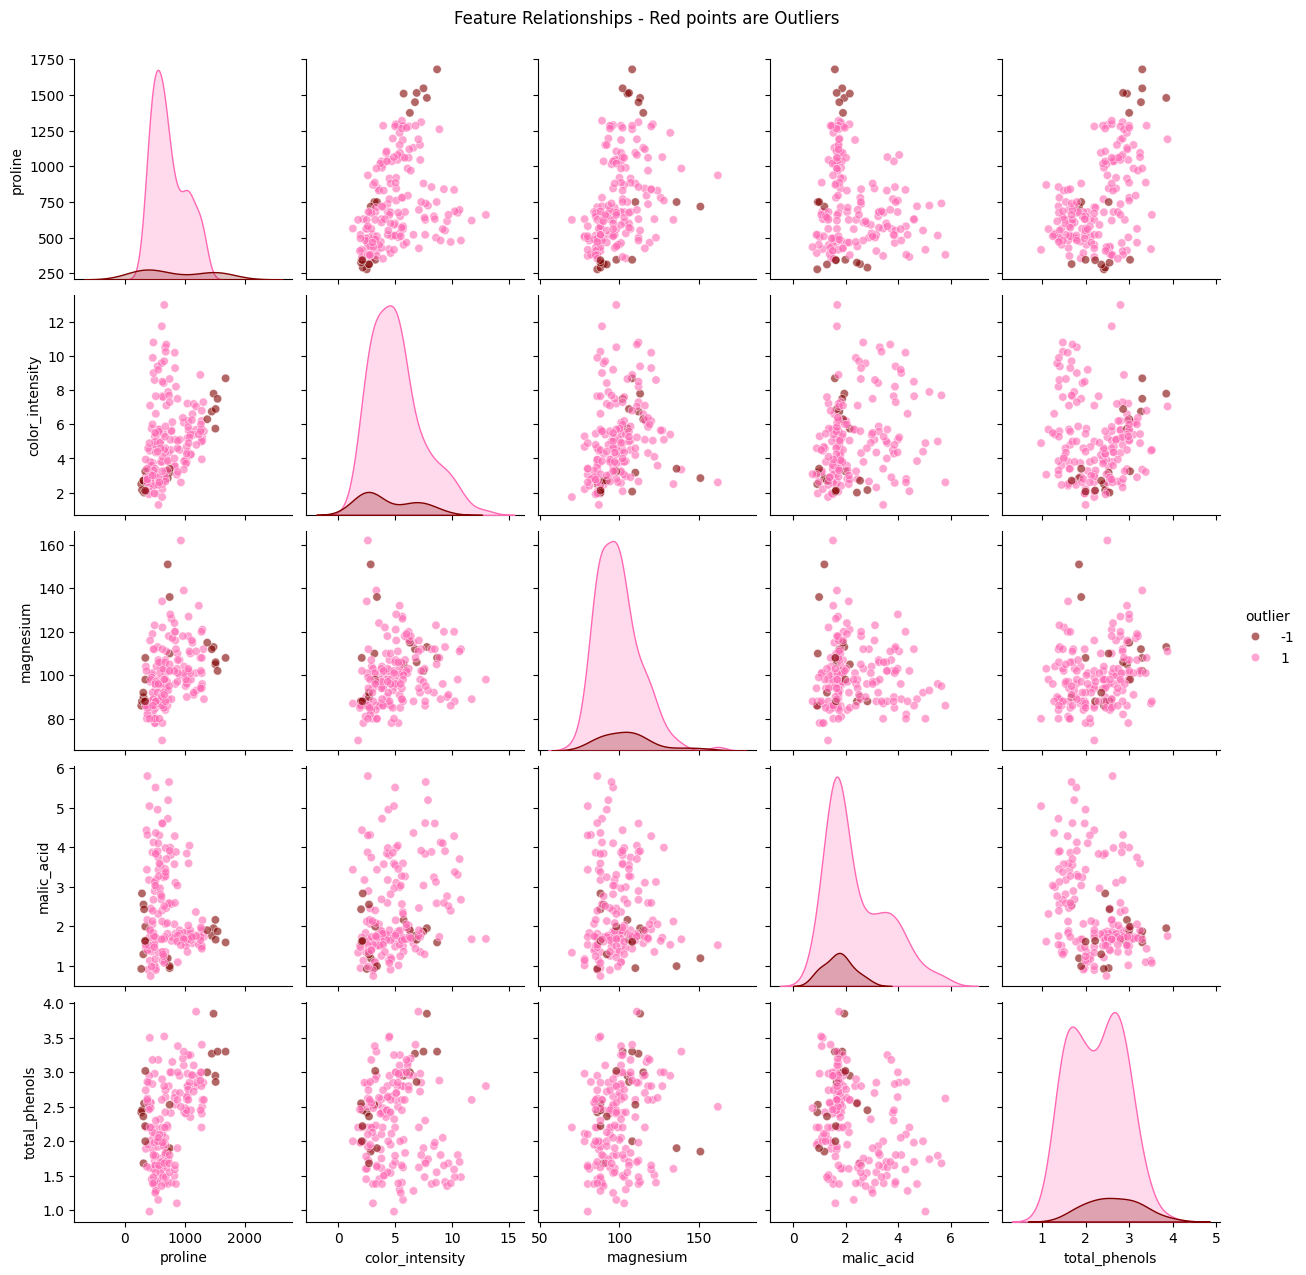

In [17]:
# Plot relationships between features And outliers of features
sns.pairplot(X[['proline', 'color_intensity', 'magnesium','malic_acid', 'total_phenols', 'outlier']], 
             hue='outlier', 
             palette={1: 'hotpink', -1: 'maroon'},
             plot_kws={'alpha': 0.6})
plt.suptitle('Feature Relationships - Red points are Outliers', y=1.02)
plt.show()

In [18]:
# Detect outliers using LOF on features
#clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
outlier_labels = clf.fit_predict(X)  # -1 = outlier, 1 = inlier

# Add to dataframe
X['feature_outlier'] = outlier_labels

# Also check for extreme alcohol values (target outliers)
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X['target_outlier'] = ((y < lower_bound) | (y > upper_bound)).astype(int)
X['target_outlier'] = X['target_outlier'].map({0: 1, 1: -1})  # Align with LOF format

# Combined outlier definition
X['is_outlier'] = (X['feature_outlier'] == -1) | (X['target_outlier'] == -1)

print(f"Feature outliers: {(X['feature_outlier'] == -1).sum()}")
print(f"Target (alcohol) outliers: {(X['target_outlier'] == -1).sum()}")
print(f"Combined outliers: {X['is_outlier'].sum()}")

Feature outliers: 18
Target (alcohol) outliers: 0
Combined outliers: 18


#### 4. Train_Test_Split Data:


=== Final Model Performance  ===
RF-MSE: 0.137
RF-RMSE: 0.370
RF-R2 Score: 0.771


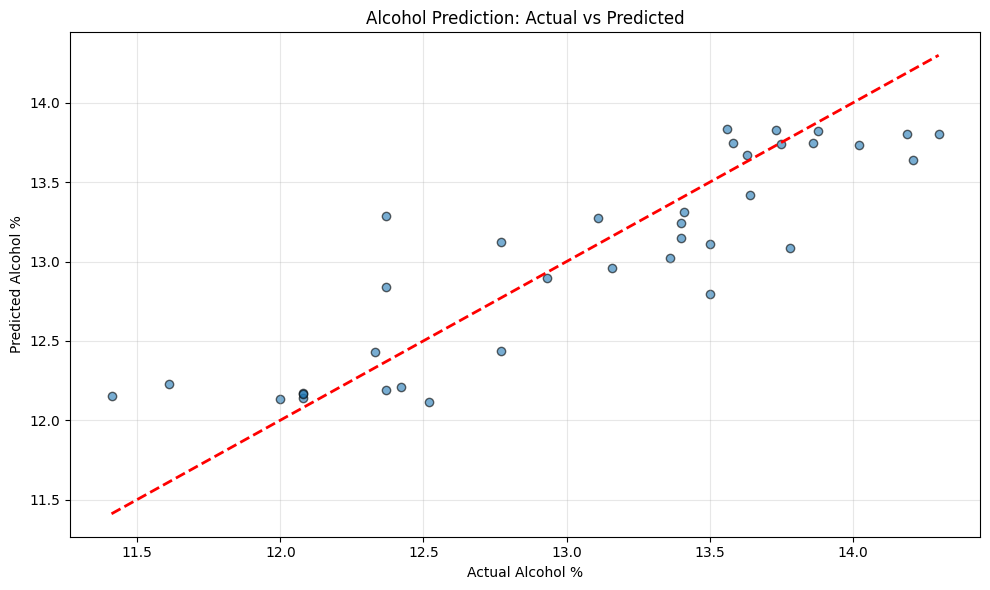

In [19]:
# For regression, using robust handling less sensitive to outliers
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Split whole data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Save evaluate models results
result_1 = []

# Create pipeline with robust scaling
pipeline_rf = Pipeline([
    ('scaler', RobustScaler()),  
    ('RF_regressor', RandomForestRegressor( # 0.750
        n_estimators=500, 
        max_depth=7,
        min_samples_split=2,
        max_features=0.7, 
        min_samples_leaf=6,
        random_state=42))
])

# Train
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Evaluate
print("\n=== Final Model Performance  ===")
print(f"RF-MSE: {mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"RF-RMSE: {root_mean_squared_error(y_test, y_pred_rf):.3f}")
print(f"RF-R2 Score: {r2_score(y_test, y_pred_rf):.3f}")

# Save result in list
result_1.append({
        'model_name': 'Random Forest',
        'mse': mean_squared_error(y_test, y_pred_rf),
        'r2': r2_score(y_test, y_pred_rf)
    })

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Alcohol %')
plt.ylabel('Predicted Alcohol %')
plt.title('Alcohol Prediction: Actual vs Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

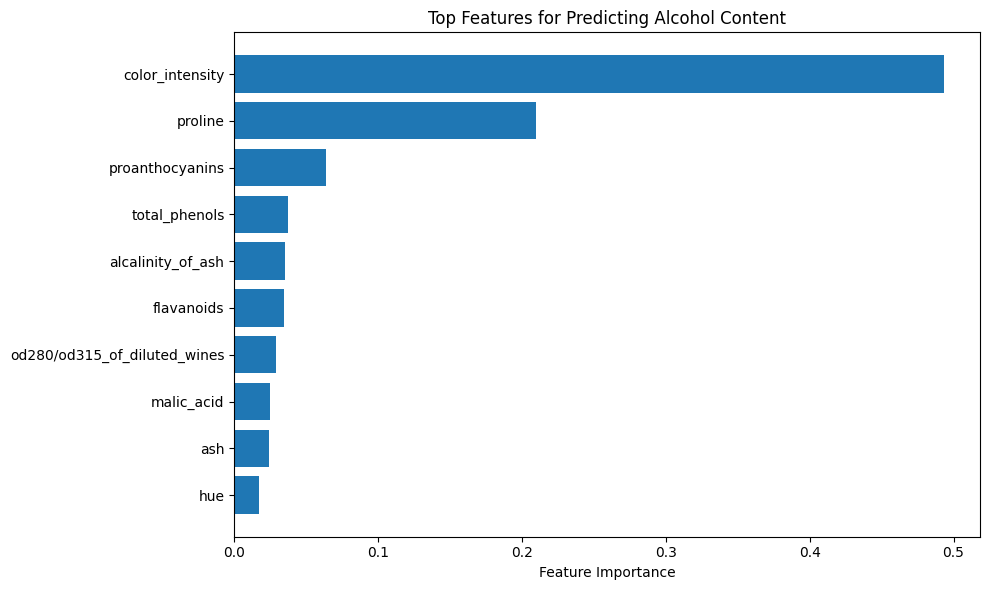


Top 5 most important features for alcohol prediction:
              Feature  Importance
8     color_intensity    0.493694
11            proline    0.209801
7     proanthocyanins    0.063991
4       total_phenols    0.037374
2   alcalinity_of_ash    0.035567


In [20]:
# Feature Importance Analysis -> which features most influence alcohol prediction
feature_names = X.columns
feature_importance = pipeline_rf.named_steps['RF_regressor'].feature_importances_
feature_names = [f for f in feature_names if f != 'alcohol']

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
plt.xlabel('Feature Importance')
plt.title('Top Features for Predicting Alcohol Content')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features for alcohol prediction:")
print(importance_df.head())

#### 5. Evaluate Models:

* Other Regressor Models in continue:

    - Linear Regression

    - KNN Regression

    - Decision Tree Regression

    - XGBoost Regressor

    - CatBoost Regressor

    - LightGBM Regressor

    - SVR

In [21]:
# Linear Regression
pipeline_lr = Pipeline([
    ('scaler', RobustScaler()),  
    ('LR-regressor', LinearRegression())
])

# Train
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# Evaluate
print("\n=== Final Linear Regression Performance ===")
print(f"LR-MSE: {mean_squared_error(y_test, y_pred_lr):.3f}")
print(f"LR-RMSE: {root_mean_squared_error(y_test, y_pred_lr):.3f}")
print(f"LR-R2 Score: {r2_score(y_test, y_pred_lr):.3f}")

# Save result in list
result_1.append({
        'model_name': 'Linear Regression',
        'mse': mean_squared_error(y_test, y_pred_lr),
        'r2': r2_score(y_test, y_pred_lr)
    })


=== Final Linear Regression Performance ===
LR-MSE: 0.188
LR-RMSE: 0.433
LR-R2 Score: 0.685


In [22]:
# KNN Regression
pipeline_knn = Pipeline([
    ('scaler', RobustScaler()),  
    ('KNN-regressor', KNeighborsRegressor(
        n_neighbors=5,
        weights='distance',
        algorithm='kd_tree', # ‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’
        leaf_size=30
    ))
])

# Train
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

# Evaluate
print("\n=== Final KNN Regression Performance ===")
print(f"KNN-MSE: {mean_squared_error(y_test, y_pred_knn):.3f}")
print(f"KNN-RMSE: {root_mean_squared_error(y_test, y_pred_knn):.3f}")
print(f"KNN-R2 Score: {r2_score(y_test, y_pred_knn):.3f}")

result_1.append({
        'model_name': 'KNN',
        'mse': mean_squared_error(y_test, y_pred_knn),
        'r2': r2_score(y_test, y_pred_knn)
    })


=== Final KNN Regression Performance ===
KNN-MSE: 0.184
KNN-RMSE: 0.429
KNN-R2 Score: 0.691


In [23]:
# Decision Tree Regression
pipeline_dtr = Pipeline([
    ('scaler', RobustScaler()),  
    ('DTR-regressor', DecisionTreeRegressor(
        criterion='squared_error', # “squared_error”, “absolute_error”, “poisson”
        splitter='random', 
        max_depth=8,
        min_samples_split=6,
        max_features='log2', # “sqrt”, “log2”
        random_state=42
    ))
])

# Train
pipeline_dtr.fit(X_train, y_train)
y_pred_dtr = pipeline_dtr.predict(X_test)

# Evaluate
print("\n=== Final Decision Tree Performance ===")
print(f"DTR-MSE: {mean_squared_error(y_test, y_pred_dtr):.3f}")
print(f"DTR-RMSE: {root_mean_squared_error(y_test, y_pred_dtr):.3f}")
print(f"DTR-R2 Score: {r2_score(y_test, y_pred_dtr):.3f}")

result_1.append({
        'model_name': 'Decision Tree',
        'mse': mean_squared_error(y_test, y_pred_dtr),
        'r2': r2_score(y_test, y_pred_dtr)
    })


=== Final Decision Tree Performance ===
DTR-MSE: 0.232
DTR-RMSE: 0.482
DTR-R2 Score: 0.611


In [24]:
# XGBoost Regressor
pipeline_xgb = Pipeline([
    ('scaler', RobustScaler()),  
    ('XGB-regressor', XGBRegressor(
        n_estimators=200,
        silent=0,
        learning_rate=0.01, 
        max_depth=3, 
        subsample=0.4, 
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=4 
    ))
])

# Train
pipeline_xgb.fit(X_train, y_train)
y_pred_xgb = pipeline_xgb.predict(X_test)

# Evaluate
print("\n=== Final XGBoost Performance ===")
print(f"XGB-MSE: {mean_squared_error(y_test, y_pred_xgb):.3f}")
print(f"XGB-RMSE: {root_mean_squared_error(y_test, y_pred_xgb):.3f}")
print(f"XGB-R2 Score: {r2_score(y_test, y_pred_xgb):.3f}")

result_1.append({
        'model_name': 'XGBoost',
        'mse': mean_squared_error(y_test, y_pred_xgb),
        'r2': r2_score(y_test, y_pred_xgb)
    })


=== Final XGBoost Performance ===
XGB-MSE: 0.162
XGB-RMSE: 0.403
XGB-R2 Score: 0.728


In [25]:
# CatBoost Regressor
pipeline_cb = Pipeline([
    ('scaler', RobustScaler()),  
    ('CB-regressor', CatBoostRegressor(
        n_estimators=400,
        boosting_type= 'Ordered', 
        learning_rate=0.01,
        depth=5,
        l2_leaf_reg=2,
        model_size_reg=5,
        verbose=0
    ))
])

# Train
pipeline_cb.fit(X_train, y_train)
y_pred_cb = pipeline_cb.predict(X_test)

# Evaluate
print("\n=== Final CatBoost Performance ===")
print(f"CB-MSE: {mean_squared_error(y_test, y_pred_cb):.3f}")
print(f"CB-RMSE: {root_mean_squared_error(y_test, y_pred_cb):.3f}")
print(f"CB-R2 Score: {r2_score(y_test, y_pred_cb):.3f}")

result_1.append({
        'model_name': 'CatBoost',
        'mse': mean_squared_error(y_test, y_pred_cb),
        'r2': r2_score(y_test, y_pred_cb)
    })


=== Final CatBoost Performance ===
CB-MSE: 0.132
CB-RMSE: 0.364
CB-R2 Score: 0.779


In [26]:
# LightGBM Regressor
pipeline_lgb = Pipeline([
    ('scaler', RobustScaler()),  
    ('LGB-regressor', LGBMRegressor(
        n_estimators=600,
        learning_rate=0.005,
        num_leaves=5, 
        max_depth=5,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        min_data_in_leaf=15,
        verbosity=-1
    ))
])

# Train
pipeline_lgb.fit(X_train, y_train)
y_pred_lgb = pipeline_lgb.predict(X_test)

# Evaluate
print("\n=== Final LightGBM Performance ===")
print(f"LGB-MSE: {mean_squared_error(y_test, y_pred_lgb):.3f}")
print(f"LGB-RMSE: {root_mean_squared_error(y_test, y_pred_lgb):.3f}")
print(f"LGB-R2 Score: {r2_score(y_test, y_pred_lgb):.3f}")

result_1.append({
        'model_name': 'LightGBM',
        'mse': mean_squared_error(y_test, y_pred_lgb),
        'r2': r2_score(y_test, y_pred_lgb)
    })


=== Final LightGBM Performance ===
LGB-MSE: 0.143
LGB-RMSE: 0.378
LGB-R2 Score: 0.761


In [27]:
# SVR
pipeline_svr = Pipeline([
    ('scaler', RobustScaler()),  
    ('SVR', SVR(
            kernel='rbf', 
            C=1.0, 
            epsilon=0.1,
            ))
])

# Train
pipeline_svr.fit(X_train, y_train)
y_pred_svr = pipeline_svr.predict(X_test)

# Evaluate
print("\n=== Final SVR Performance ===")
print(f"SVR-MSE: {mean_squared_error(y_test, y_pred_svr):.3f}")
print(f"SVR-RMSE: {root_mean_squared_error(y_test, y_pred_svr):.3f}")
print(f"SVR-R2 Score: {r2_score(y_test, y_pred_svr):.3f}")

result_1.append({
        'model_name': 'SVR',
        'mse': mean_squared_error(y_test, y_pred_svr),
        'r2': r2_score(y_test, y_pred_svr)
    })



=== Final SVR Performance ===
SVR-MSE: 0.157
SVR-RMSE: 0.397
SVR-R2 Score: 0.736


In [28]:
# Sort results by R2 score (descending)
results_sorted_1 = sorted(result_1, key=lambda x: x['r2'], reverse=True)

# Print sorted results
BOLD = '\033[1m'
RESET = '\033[0m'

print(f"\n{'='*60}")
print(f"{BOLD}RESULTS SORTED BY R² SCORE (Best to Worst){RESET}")
print(f"{'='*60}")

for idx, result in enumerate(results_sorted_1, 1):
    print(f"{idx}. {BOLD}{result['model_name']}{RESET}: R² = {result['r2']:.4f}, MSE = {result['mse']:.4f}")

# Show best model
best_model = results_sorted_1[0]
print(f"\n{'='*60}")
print(f"{BOLD}🏆 BEST MODEL: {best_model['model_name']}{RESET}")
print(f"{BOLD}   R² Score: {best_model['r2']:.4f}{RESET}")
print(f"{BOLD}   MSE: {best_model['mse']:.4f}{RESET}")
print(f"{'='*60}")


RESULTS SORTED BY R² SCORE (Best to Worst)
1. CatBoost: R² = 0.7786, MSE = 0.1322
2. Random Forest: R² = 0.7710, MSE = 0.1367
3. LightGBM: R² = 0.7607, MSE = 0.1428
4. SVR: R² = 0.7363, MSE = 0.1574
5. XGBoost: R² = 0.7284, MSE = 0.1621
6. KNN: R² = 0.6913, MSE = 0.1843
7. Linear Regression: R² = 0.6853, MSE = 0.1879
8. Decision Tree: R² = 0.6113, MSE = 0.2320

🏆 BEST MODEL: CatBoost
   R² Score: 0.7786
   MSE: 0.1322


---------------------------------------------------------

## Part 2:

### Work on Feature Selection and Tunning:

#### 1. Data:

In [30]:
data = load_wine().data
df = pd.DataFrame(data, columns=load_wine().feature_names)
feature_names = load_wine().feature_names

X = df.drop('alcohol', axis=1)
y = df['alcohol']

df.shape  
#X.shape   
#y.shape   

(178, 13)

#### 2. Describe:

In [31]:
df.describe().loc[['min', 'max']].T

,min,max
alcohol,11.03,14.83
malic_acid,0.74,5.80
ash,1.36,3.23
alcalinity_of_ash,10.60,30.00
magnesium,70.00,162.00
total_phenols,0.98,3.88
flavanoids,0.34,5.08
nonflavanoid_phenols,0.13,0.66
proanthocyanins,0.41,3.58
color_intensity,1.28,13.00


In [32]:
# null values
X.isna().sum().sum() 

np.int64(0)

In [33]:
# Duplicate values
X.duplicated().sum()

np.int64(0)

In [34]:
X.info

<bound method DataFrame.info of      malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0          1.71  2.43               15.6      127.0           2.80   
1          1.78  2.14               11.2      100.0           2.65   
2          2.36  2.67               18.6      101.0           2.80   
3          1.95  2.50               16.8      113.0           3.85   
4          2.59  2.87               21.0      118.0           2.80   
..          ...   ...                ...        ...            ...   
173        5.65  2.45               20.5       95.0           1.68   
174        3.91  2.48               23.0      102.0           1.80   
175        4.28  2.26               20.0      120.0           1.59   
176        2.59  2.37               20.0      120.0           1.65   
177        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0          3.06                  0.28         

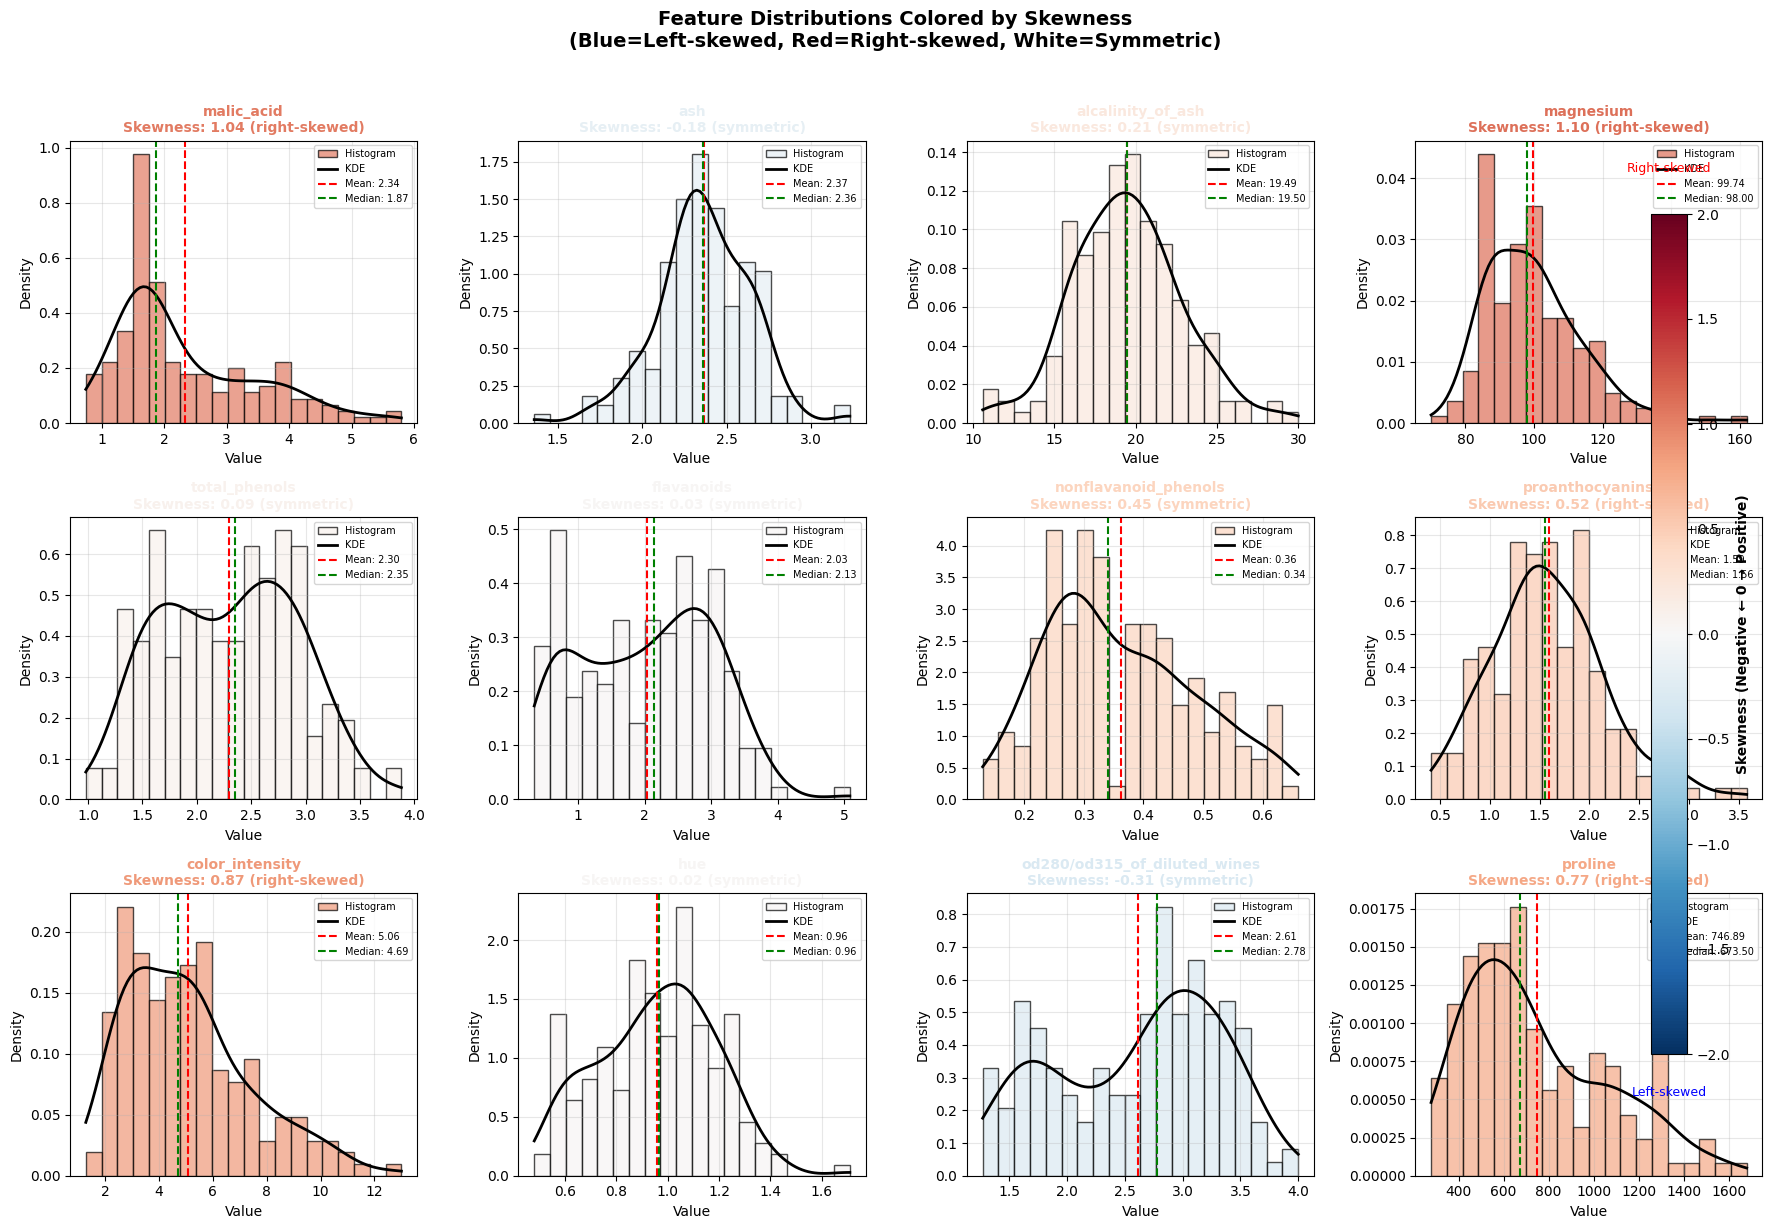

In [44]:
def plot_distributions_gradient_by_skewness_enhanced(df, n_cols=3, figsize=(15, 10)):
    """
    Enhanced version with more statistical information
    """
    from matplotlib.cm import RdBu_r
    from matplotlib.colors import Normalize
    
    n_features = len(df.columns)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Calculate skewness for each column
    skewness = {col: df[col].skew() for col in df.columns}
    
    # Create colormap for skewness
    norm = Normalize(vmin=-2, vmax=2)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, column in enumerate(df.columns):
        # Get color based on skewness
        skew_val = skewness[column]
        color = RdBu_r(norm(skew_val))
        
        # Create histogram with KDE
        axes[i].hist(df[column], bins=20, edgecolor='black', alpha=0.7, 
                    color=color, density=True, label='Histogram')
        
        # Add KDE line
        from scipy import stats
        kde = stats.gaussian_kde(df[column])
        x_range = np.linspace(df[column].min(), df[column].max(), 100)
        axes[i].plot(x_range, kde(x_range), 'k-', linewidth=2, label='KDE')
        
        # Title with skewness information
        skew_interpretation = "symmetric" if abs(skew_val) < 0.5 else \
                             "right-skewed" if skew_val > 0 else "left-skewed"
        axes[i].set_title(f'{column}\nSkewness: {skew_val:.2f} ({skew_interpretation})', 
                         fontsize=10, fontweight='bold', color=color)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        
        # Add mean, median, mode lines
        mean_val = df[column].mean()
        median_val = df[column].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
                       label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='--', linewidth=1.5, 
                       label=f'Median: {median_val:.2f}')
        
        axes[i].legend(fontsize=7, loc='upper right')
        axes[i].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=RdBu_r, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Skewness (Negative ← 0 → Positive)', fontsize=10, fontweight='bold')
    cbar.ax.text(0.5, -0.05, 'Left-skewed', transform=cbar.ax.transAxes, 
                ha='center', fontsize=9, color='blue')
    cbar.ax.text(0.5, 1.05, 'Right-skewed', transform=cbar.ax.transAxes, 
                ha='center', fontsize=9, color='red')
    
    # Remove empty subplots
    for i in range(n_features, len(axes)):
        fig.delaxes(axes[i])
    
    plt.suptitle('Feature Distributions Colored by Skewness\n(Blue=Left-skewed, Red=Right-skewed, White=Symmetric)', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig, axes

# Usage
fig, axes = plot_distributions_gradient_by_skewness_enhanced(X, n_cols=4, figsize=(18, 12))
plt.show()

#### 3. Train & Test Split on Dataset:

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42,
)

#### 4. Scale the features:

In [46]:
mms = MinMaxScaler()
X_train = mms.fit_transform(X_train)
X_test = mms.transform(X_test)

#### 5. Create a Lasso Regression model:

With a specific alpha(regularization strenght)

In [47]:
# from linear models import Lasso
lasso =Lasso(alpha=0.01) # landa in formula
lasso.fit(X_train, y_train)
coefficients = lasso.coef_

#### 6. Feature Importance:

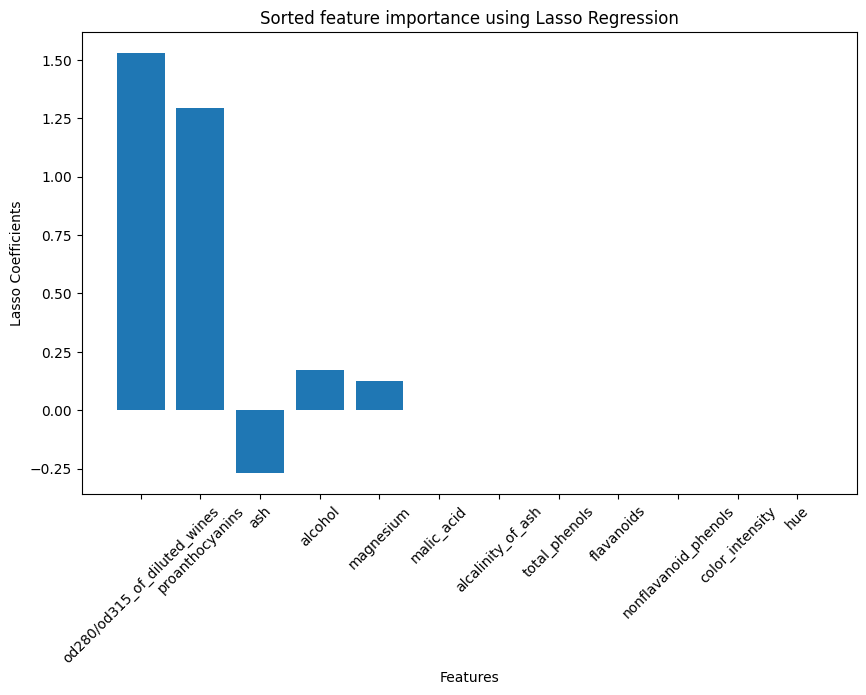

Features sorted by importance(most to less):
od280/od315_of_diluted_wines : 1.5294
proanthocyanins : 1.2937
ash : -0.2693
alcohol : 0.1701
magnesium : 0.1262
malic_acid : 0.0000
alcalinity_of_ash : -0.0000
total_phenols : 0.0000
flavanoids : -0.0000
nonflavanoid_phenols : -0.0000
color_intensity : 0.0000
hue : 0.0000


In [48]:
# combine feature names and coefficients into a list of tuples
featue_importance = list(zip(feature_names, coefficients))

# sort the features by the absolute values of their coefficients in descending order
sorted_features = sorted(featue_importance, key=lambda x: abs(x[1]), reverse=True)

# Extract the sorted feature names
sorted_feature_names = [feature for feature, coef in sorted_features]

# Plot the sorted coeeficients
sorted_coefficients = [coef for feature, coef in sorted_features]

plt.figure(figsize=(10, 6))
plt.bar(
    sorted_feature_names, 
    sorted_coefficients,
    )
plt.xlabel('Features')
plt.ylabel('Lasso Coefficients')
plt.title('Sorted feature importance using Lasso Regression')
plt.xticks(rotation=45)
plt.show()

# Print the sorted features from the most important to the less important
print('Features sorted by importance(most to less):')
for feature, coef in sorted_features:
    print(f'{feature} : {coef:.4f}')
    

#### 7. Sort Features:

In [49]:
# Extract the sorted feature names
important_features = [feature for feature, coef in sorted_features if coef != 0]
print('Selected features: ', important_features)

# Create a new dataset with only important features
X_train_selected = X_train[:, [feature_names.index(f) for f in important_features]]
X_test_selected = X_test[:, [feature_names.index(f) for f in important_features]]


Selected features:  ['od280/od315_of_diluted_wines', 'proanthocyanins', 'ash', 'alcohol', 'magnesium']


#### 8. Models to Evaluate:

In [50]:

models = {
    'LR' : LinearRegression(),
    'KNN': KNeighborsRegressor(
        n_neighbors=5,
        weights='distance',
        algorithm='kd_tree', 
        leaf_size=30),
    'Decision Tree': DecisionTreeRegressor(
        criterion='squared_error', 
        splitter='random', 
        max_depth=8,
        min_samples_split=6,
        max_features='log2', 
        random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=500, 
        max_depth=7,
        min_samples_split=2,
        max_features=0.7, 
        min_samples_leaf=6,
        random_state=42),
    'CatBoost': CatBoostRegressor(
        n_estimators=400,
        boosting_type= 'Ordered', 
        learning_rate=0.01,
        depth=5,
        l2_leaf_reg=2,
        model_size_reg=5,
        verbose=0),
    'XGBoost': XGBRegressor(
        n_estimators=200,
        silent=0,
        learning_rate=0.01, 
        max_depth=3, 
        subsample=0.4, 
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=4 ),
    'LightGBM': LGBMRegressor(
        n_estimators=600,
        learning_rate=0.005,
        num_leaves=5, 
        max_depth=5,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        min_data_in_leaf=15,
        verbosity=-1
    ),
    'SVR' : SVR(
        kernel='rbf', 
        C=1.0, 
        epsilon=0.1,
        )
}

#### 9. Train & Evaluate each Model:

In [51]:
# Store results in a list
results = []

for model_name, model in models.items():
    print(f'\nTraining {model_name} ...')
    model.fit(X_train_selected, y_train)  # Fixed typo: X_trin_selected -> X_train_selected

    # Predict & Evaluate
    y_pred = model.predict(X_test_selected)
    mse = mean_squared_error(y_test, y_pred) 
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'model_name': model_name,
        'mse': mse,
        'r2': r2
    })

# Sort results by R2 score (descending)
results_sorted = sorted(results, key=lambda x: x['r2'], reverse=True)

# Print sorted results
BOLD = '\033[1m'
RESET = '\033[0m'

print(f"\n{'='*60}")
print(f"{BOLD}RESULTS SORTED BY R² SCORE (Best to Worst){RESET}")
print(f"{'='*60}")

for idx, result in enumerate(results_sorted, 1):
    print(f"{idx}. {BOLD}{result['model_name']}{RESET}: R² = {result['r2']:.4f}, MSE = {result['mse']:.4f}")

# Show best model
best_model = results_sorted[0]
print(f"\n{'='*60}")
print(f"{BOLD}🏆 BEST MODEL: {best_model['model_name']}{RESET}")
print(f"{BOLD}   R² Score: {best_model['r2']:.4f}{RESET}")
print(f"{BOLD}   MSE: {best_model['mse']:.4f}{RESET}")
print(f"{'='*60}")


Training LR ...

Training KNN ...

Training Decision Tree ...

Training Random Forest ...

Training CatBoost ...

Training XGBoost ...

Training LightGBM ...

Training SVR ...

RESULTS SORTED BY R² SCORE (Best to Worst)
1. LightGBM: R² = 0.7957, MSE = 0.1220
2. CatBoost: R² = 0.7932, MSE = 0.1235
3. Random Forest: R² = 0.7873, MSE = 0.1270
4. KNN: R² = 0.7868, MSE = 0.1273
5. XGBoost: R² = 0.7514, MSE = 0.1484
6. SVR: R² = 0.7287, MSE = 0.1620
7. LR: R² = 0.7150, MSE = 0.1701
8. Decision Tree: R² = 0.5252, MSE = 0.2835

🏆 BEST MODEL: LightGBM
   R² Score: 0.7957
   MSE: 0.1220
